# Feedback Outcome Decoding

This notebook reads saved feedback-locked epochs with metadata and compares outcome decodability across task contexts, using `decoding.epoch_io.py`, `window_decoding_utils.py`

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
REPO_ROOT = next(path for path in (cwd, *cwd.parents) if (path / 'scripts' / 'config.py').exists())
SCRIPTS_DIR = REPO_ROOT / 'scripts'
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

import config
EPOCHS_ROOT = REPO_ROOT / 'output_mne' / 'epochs'

from decoding.decoding_utils.plotting import plot_window_decoding_summary
from decoding.decoding_utils.window_decoding_utils import run_group_decoding_window
from decoding.decoding_utils.epoch_io import get_epochs_path


In [5]:
PIPELINE = 'proposed'
CONTEXTS = ['mid_high', 'high_high']
WINDOW_START = 0.24
WINDOW_END = 0.34
# SUBJECTS = sorted(config.SUBJECT_INFO)
SUBJECTS = sorted(
    sub for sub, info in config.SUBJECT_INFO.items()
    if info["learner"]
)

subjects_to_run = [
    sid for sid in SUBJECTS
    if get_epochs_path(sid, PIPELINE, 'feedback', root_dir=EPOCHS_ROOT).exists()
]
if not subjects_to_run:
    raise FileNotFoundError('No saved feedback epochs found. Run make_feedback_epochs.ipynb first.')

summary_df, _, _ = run_group_decoding_window(
    subjects_to_run,
    PIPELINE,
    CONTEXTS,
    window_start=WINDOW_START,
    window_end=WINDOW_END,
    root_dir=EPOCHS_ROOT,
)
summary_df


,subject_id,context,n_trials,n_win,n_loss,cv_splits,window_start_sec,window_end_sec,mean_auc,std_auc
0,27,mid_high,67,42,25,5,0.24,0.34,0.615556,0.194232
1,27,high_high,133,77,56,5,0.24,0.34,0.626894,0.116842
2,28,mid_high,53,45,8,5,0.24,0.34,0.611111,0.426730
3,28,high_high,32,27,5,5,0.24,0.34,0.486667,0.119257
4,31,mid_high,64,41,23,5,0.24,0.34,0.751389,0.167579
5,31,high_high,131,95,36,5,0.24,0.34,0.779511,0.048343
6,34,mid_high,65,44,21,5,0.24,0.34,0.465556,0.095775
7,34,high_high,132,88,44,5,0.24,0.34,0.497449,0.108365
8,35,mid_high,59,48,11,5,0.24,0.34,0.514444,0.413835
9,35,high_high,129,82,47,5,0.24,0.34,0.672296,0.150372


context,high_high,mid_high
subject_id,,
27,0.626894,0.615556
28,0.486667,0.611111
31,0.779511,0.751389
34,0.497449,0.465556
35,0.672296,0.514444
36,0.732111,0.737778
37,0.762494,0.627778
38,0.771742,0.519259


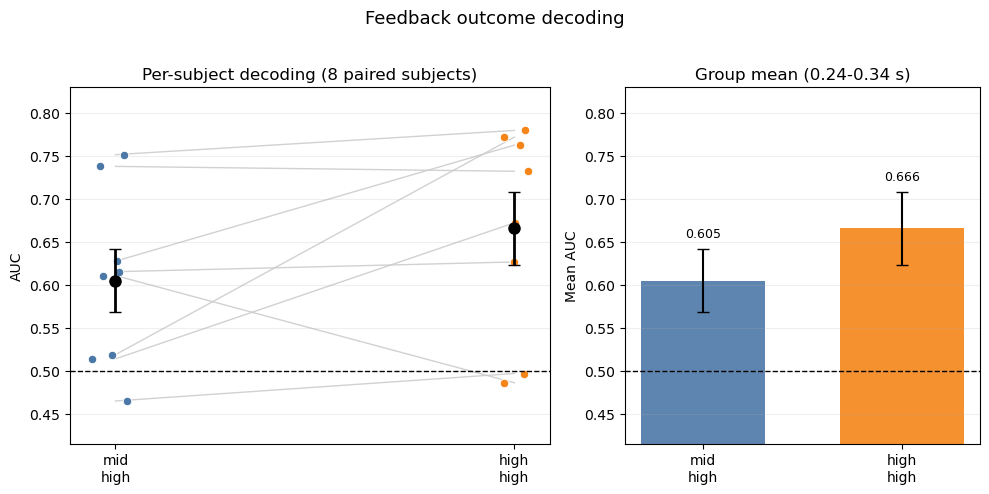

In [6]:
fig, axes, paired_df = plot_window_decoding_summary(
    summary_df,
    CONTEXTS,
    WINDOW_START,
    WINDOW_END,
)
paired_df